In [21]:
!pip install keras-tuner


   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   ---------------------------------------- 2/2 [keras-tuner]



In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.optimizers import Adam
import kerastuner as kt
import os
import matplotlib.pyplot as plt

In [24]:
data_path = r'C:\Users\User\OneDrive\Desktop\AIML\outputs\outputs'

In [15]:
categories = os.listdir(data_path)
print(categories)

['Disappointed', 'Interested', 'Neutral']


In [16]:
img_height = 50
img_width = 50

img_size = (img_height, img_width)
b_size = 64

In [17]:
print("Loading training data....")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = img_size,
    batch_size = b_size,
    color_mode = 'grayscale'
)

Loading training data....
Found 34395 files belonging to 3 classes.
Using 27516 files for training.


In [18]:
print("Loading validation data...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split = 0.2,
    subset = "validation",
    seed = 123, # Using a seed ensures the split is reproducible
    image_size = img_size,
    batch_size = b_size,
    color_mode = 'grayscale'
)

Loading validation data...
Found 34395 files belonging to 3 classes.
Using 6879 files for validation.


In [19]:
class_names = train_dataset.class_names
print(f"Found class names: {class_names}")

Found class names: ['Disappointed', 'Interested', 'Neutral']


In [57]:
# Optimize performance by caching and prefetching the data
autotune = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size = autotune)
validation_dataset = validation_dataset.cache().prefetch(buffer_size = autotune)

In [26]:
# --- DEFINE THE MODEL-BUILDING FUNCTION ---

In [27]:
def build_model(hp):
    model = Sequential()
    
    model.add(Input(shape=(img_height, img_width, 1)))
    
    model.add(RandomFlip("horizontal"))
    model.add(RandomRotation(0.1))
    model.add(Rescaling(1./255))
    
    model.add(Conv2D(
        filters=hp.Int('conv_1_filters', min_value=32, max_value=128, step=32),
        kernel_size=(3, 3),
        activation='relu',
        padding='same'
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))


    model.add(Conv2D(
        filters=hp.Int('conv_2_filters', min_value=64, max_value=256, step=64),
        kernel_size=(3, 3),
        activation='relu',
        padding='same'
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    
    model.add(Flatten())
    
    model.add(Dense(
        units=hp.Int('dense_units', min_value=128, max_value=512, step=128),
        activation='relu'
    ))
    
    model.add(Dropout(
        rate=hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
    ))
    
    model.add(Dense(3, activation='softmax'))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4])
    
    model.compile(
        optimizer=Adam(learning_rate=hp_learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [28]:
# --- CREATE AND RUN THE HYPERPARAMETER SEARCH ---

In [29]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,
    factor=3,
    directory='kt_dir',
    project_name='facial_expression'
)

tuner.search_space_summary()

Search space summary
Default search space size: 5
conv_1_filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
conv_2_filters (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 512, 'step': 128, 'sampling': 'linear'}
dropout_rate (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


In [31]:
print("\nStarting hyperparameter search... ")
tuner.search(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3)] 
)

print("\nSearch complete.")

Trial 90 Complete [01h 00m 17s]
val_accuracy: 0.6577991247177124

Best val_accuracy So Far: 0.6634685397148132
Total elapsed time: 15h 58m 19s

Search complete.


In [52]:
best_hps = tuner.get_best_hyperparameters()[0]

print(f"""
Search complete. The optimal hyperparameters are:
 Conv 1 Filters: {best_hps.get('conv_1_filters')}
 Conv 2 Filters: {best_hps.get('conv_2_filters')}
 Dense Units: {best_hps.get('dense_units')}
 Dropout Rate: {best_hps.get('dropout_rate'):.2f}
 Learning Rate: {best_hps.get('learning_rate')}
""")


Search complete. The optimal hyperparameters are:
 Conv 1 Filters: 32
 Conv 2 Filters: 192
 Dense Units: 512
 Dropout Rate: 0.40
 Learning Rate: 0.0001



In [60]:
# --- Find Bad Images ---

print("Starting to check all image files for corruption...")

all_filepaths_debug = []
all_labels_debug = []
image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp"]

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(data_path, class_name)
    filepaths_for_class = []
    for ext in image_extensions:
        filepaths_for_class.extend(glob.glob(os.path.join(class_dir, ext)))
    all_filepaths_debug.extend(filepaths_for_class)
    all_labels_debug.extend([i] * len(filepaths_for_class))

print(f"Total files to check: {len(all_filepaths_debug)}")
bad_files = []

for i, filepath in enumerate(all_filepaths_debug):
    
    if (i + 1) % 1000 == 0:
        print(f"Checked {i+1}/{len(all_filepaths_debug)} files...")
        
    try:
        img_bytes = tf.io.read_file(filepath)
        
        img = tf.image.decode_image(img_bytes, channels=CHANNELS)
        
        if tf.shape(img)[0] == 0 or tf.shape(img)[1] == 0:
            print(f"EMPTY IMAGE FOUND: {filepath}")
            bad_files.append(filepath)
            
    except Exception as e:
        print(f"--- CORRUPTED FILE FOUND ---")
        print(f"File: {filepath}")
        print(f"Error: {e}")
        print("------------------------------")
        bad_files.append(filepath)

print("\n--- CHECK COMPLETE ---")
if not bad_files:
    print("No corrupted or empty files found.")
else:
    print(f"Found {len(bad_files)} problematic file(s):")
    for f in bad_files:
        print(f)
print("------------------------")

Starting to check all image files for corruption...
Total files to check: 34395
Checked 1000/34395 files...
Checked 2000/34395 files...
Checked 3000/34395 files...
Checked 4000/34395 files...
Checked 5000/34395 files...
Checked 6000/34395 files...
Checked 7000/34395 files...
Checked 8000/34395 files...
Checked 9000/34395 files...
Checked 10000/34395 files...
Checked 11000/34395 files...
Checked 12000/34395 files...
Checked 13000/34395 files...
Checked 14000/34395 files...
Checked 15000/34395 files...
Checked 16000/34395 files...
Checked 17000/34395 files...
Checked 18000/34395 files...
Checked 19000/34395 files...
Checked 20000/34395 files...
Checked 21000/34395 files...
Checked 22000/34395 files...
Checked 23000/34395 files...
Checked 24000/34395 files...
Checked 25000/34395 files...
Checked 26000/34395 files...
Checked 27000/34395 files...
Checked 28000/34395 files...
Checked 29000/34395 files...
Checked 30000/34395 files...
Checked 31000/34395 files...
Checked 32000/34395 files...
C

In [66]:
# --- TRAIN THE MODEL ---

In [67]:
print("\nTraining the model found by the tuner...")

model = tuner.get_best_models(num_models=1)[0]

EPOCHS = 100 

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

print("\nFinal training complete.")


Training the model found by the tuner...
Epoch 1/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 116s 265ms/step - accuracy: 0.6719 - loss: 0.7133 - val_accuracy: 0.6452 - val_loss: 0.7482
Epoch 2/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 112s 260ms/step - accuracy: 0.6766 - loss: 0.7053 - val_accuracy: 0.6565 - val_loss: 0.7377
Epoch 3/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 114s 266ms/step - accuracy: 0.6815 - loss: 0.6981 - val_accuracy: 0.6524 - val_loss: 0.7413
Epoch 4/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 115s 267ms/step - accuracy: 0.6850 - loss: 0.6931 - val_accuracy: 0.6574 - val_loss: 0.7370
Epoch 5/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 112s 261ms/step - accuracy: 0.6917 - loss: 0.6813 - val_accuracy: 0.6642 - val_loss: 0.7275
Epoch 6/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 112s 260ms/step - accuracy: 0.6895 - loss: 0.6833 - val_accuracy: 0.6630 - val_loss: 0.7288
Epoch 7/100
430/430 ━━━━━━━━━━━━━━━━━━━━ 111s 258ms/step - accuracy: 0.6972 - loss: 0.6692 - val_accuracy: 0.6620 - val_loss: 0.7350
Epoch 8/100
430/430 ━━━━━━━


Evaluating model on validation data....
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6847 - loss: 1.0960
Final Validation Accuracy: 68.47%


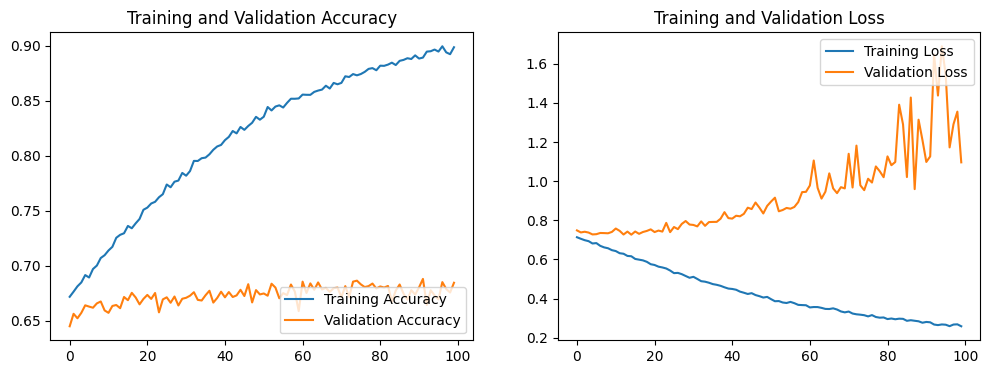

In [69]:
print("\nEvaluating model on validation data....")
loss, accuracy = model.evaluate(validation_dataset)
print(f"Final Validation Accuracy: {accuracy*100:.2f}%")


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [70]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [71]:
# ------------ The Classification Report ------------

In [72]:
print("Gathering predictions from validation set...")
y_pred = [] 
y_true = []

for images, labels in validation_dataset:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("Predictions gathered...")

print("Classification Report")
print("---" * 10)

print(classification_report(y_true, y_pred, target_names=class_names))

Gathering predictions from validation set...
Predictions gathered...
Classification Report
------------------------------
              precision    recall  f1-score   support

Disappointed       0.60      0.57      0.58      1941
  Interested       0.82      0.82      0.82      2865
     Neutral       0.58      0.61      0.59      2073

    accuracy                           0.68      6879
   macro avg       0.67      0.67      0.67      6879
weighted avg       0.69      0.68      0.69      6879



In [73]:
# ------------ The Confusion Matrix ------------

Generating Confusion Matrix...
------------------------------


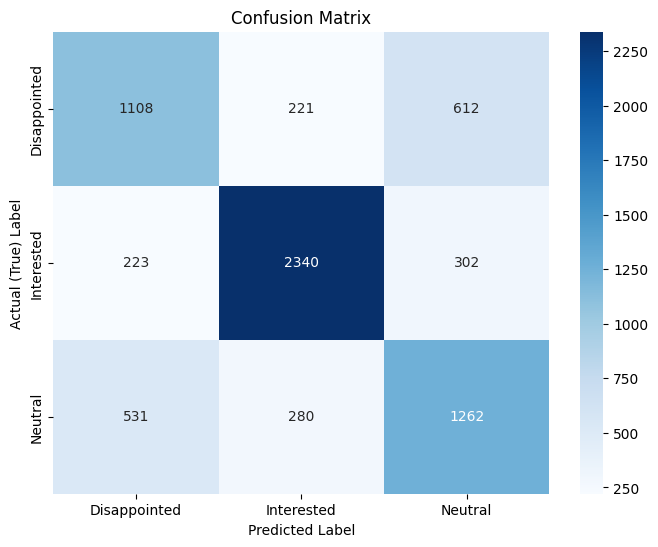

In [74]:
print("Generating Confusion Matrix...")
print("---" * 10)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel('Actual (True) Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

In [75]:
# ---  SAVE THE MODEL ---

model_filename = "IT24101757.keras"

print(f"\nSaving final model to {model_filename}...")

model.save(model_filename)

print("Model saved successfully.")


Saving final model to IT24101757.keras...
Model saved successfully.
